In [12]:
from sklearn.datasets import make_blobs
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [13]:
X,y = make_blobs(n_features = 5,centers=3,cluster_std=1.5,random_state=42,n_samples = 500)

In [14]:
X

array([[ -9.85712583,   9.52196609,   6.40680626,  -6.81757623,
         -7.86054541],
       [ -8.04717781,   8.40261648,   6.40946097,  -4.33576029,
         -6.70289196],
       [ -3.73690895,   6.7601386 ,   4.24877609,   0.28504117,
         -7.10318219],
       ...,
       [ -5.82805   ,  -7.29173339,   7.48633693,   2.71623974,
          7.33823548],
       [ -2.48648271,   9.67739715,   6.21190845,   1.03031506,
         -7.54637531],
       [ -8.63901448, -10.68852991,   8.36601977,   4.94211449,
          3.77070371]], shape=(500, 5))

In [21]:
y

array([2, 2, 0, 1, 2, 0, 0, 1, 1, 0, 0, 0, 1, 2, 2, 2, 1, 1, 0, 2, 0, 1,
       1, 2, 0, 2, 1, 1, 2, 1, 1, 0, 1, 2, 0, 0, 1, 1, 2, 2, 0, 2, 1, 2,
       0, 0, 2, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 2, 1, 2, 1, 1, 1, 0,
       2, 2, 2, 2, 1, 0, 0, 2, 1, 2, 1, 2, 2, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       2, 0, 2, 1, 0, 2, 2, 2, 2, 0, 2, 1, 0, 1, 0, 2, 1, 2, 0, 2, 0, 1,
       1, 2, 0, 1, 0, 1, 1, 1, 0, 1, 2, 0, 2, 2, 1, 0, 2, 1, 2, 0, 2, 1,
       2, 2, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 2, 2, 1, 1, 1, 0, 0,
       0, 0, 2, 2, 1, 1, 0, 2, 2, 0, 2, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       2, 0, 0, 2, 1, 1, 2, 2, 0, 0, 1, 0, 0, 1, 1, 2, 1, 2, 1, 0, 2, 2,
       0, 1, 1, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 0, 1, 1, 2, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 2, 2, 2, 1, 2, 1, 2, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       2, 0, 0, 2, 2, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 2, 2, 1, 1,
       0, 2, 1, 2, 1, 0, 1, 1, 1, 2, 0, 0, 0, 2, 0, 2, 0, 0, 1, 0, 0, 2,
       2, 2, 0, 1, 2, 0, 2, 2, 0, 0, 2, 0, 2, 2, 1,

In [15]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [16]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [17]:
X_pca

array([[ 1.40522818e+00, -1.73079914e+00],
       [ 1.03463536e+00, -9.82792414e-01],
       [ 1.10182830e+00,  1.09084050e+00],
       [-1.76465839e+00,  1.09970698e-01],
       [ 8.59673831e-01, -1.63970361e+00],
       [ 1.09738958e+00,  1.11937509e+00],
       [ 1.04453451e+00,  1.88953610e+00],
       [-3.14810185e+00, -1.06909853e-01],
       [-1.34287183e+00,  7.48033000e-01],
       [ 4.59419122e-01,  9.66806100e-01],
       [ 1.64897776e+00,  1.95384681e+00],
       [ 7.73369393e-01,  2.09584610e+00],
       [-1.92869648e+00,  9.48608771e-02],
       [ 1.15480661e+00, -1.42564791e+00],
       [ 7.07330515e-01, -1.01056640e+00],
       [ 1.59661674e+00, -1.64931961e+00],
       [-2.40550592e+00, -7.53357753e-01],
       [-1.97627695e+00, -3.59747020e-02],
       [ 1.26193015e+00,  2.72813008e+00],
       [ 1.58339885e+00, -1.46125327e+00],
       [ 1.61435981e+00,  1.29812279e+00],
       [-1.74438705e+00,  1.58820049e-01],
       [-1.88938008e+00,  3.66662930e-01],
       [ 6.

In [18]:
df = pd.DataFrame(X_pca,columns=['pca1','pca2'])

In [19]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)
df['cluster'] = cluster_labels

<Axes: xlabel='pca1', ylabel='pca2'>

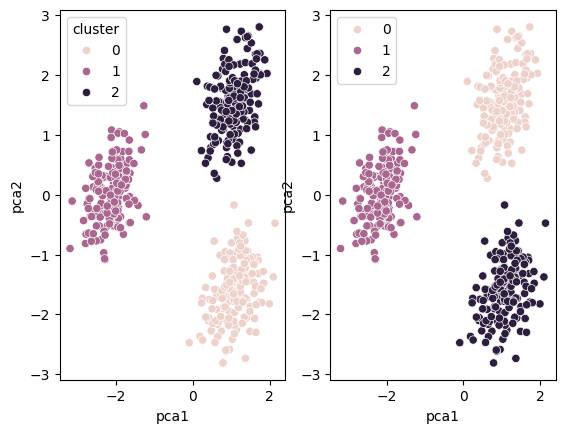

In [25]:
plt.subplot(1,2,1)
sns.scatterplot(x=df['pca1'],y=df['pca2'],hue=df['cluster'])
plt.subplot(1,2,2)
sns.scatterplot(x=df['pca1'],y=df['pca2'],hue=y)

In [22]:
(df['cluster'] == y).sum()

np.int64(167)

In [23]:
len(y)

500

In [34]:
df['cluster'].value_counts()

cluster
2    167
1    167
0    166
Name: count, dtype: int64

In [36]:
pd.DataFrame(y).value_counts()

0
0    167
1    167
2    166
Name: count, dtype: int64